# Pyaldata example notebook

In [2]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [23]:
import numpy as np
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp

## Loading

In [4]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [8]:
df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


## DataFrame overview (trial-aligned multimodal dataset)

Each session is organised as a **pandas DataFrame in “trial/segment” format**: **each row corresponds to a contiguous time window** (e.g. `free` baseline running, `trial` periods of perturbations, `intertrial` period in-between perturbations) from a given recording **session** and **animal**, with all modalities time-aligned to the same sample index.

### Identifiers and segmentation
- `animal`, `session`: subject and recording session identifiers.
- `trial_id`: integer index of the segment within the session.
- `trial_name`: categorical label describing the segment type (e.g. `free`, `trial`, `intertrial`).
- `trial_length`: number of time bins/samples in this segment.
- `bin_size`: temporal resolution of the binned signals (e.g. `0.01` = 10 ms per bin).

### Global indexing (alignment across the whole session)
- `idx_trial_start`, `idx_trial_end`: **start/end indices** of this segment **in the session-wide time base**.  
  Use these indices to slice continuous signals or to map segments back onto the full recording timeline.

### Event alignment / synchronisation
- `values_before_camera_trigger` (and related fields): metadata used to align neural/sensor/kinematic streams to external events (e.g. camera trigger) and to support consistent synchronisation across modalities.

### Neural activity (spiking)
- Columns such as `MOp_spikes` (and analogous fields for other regions) store **binned spike counts or spike indicators per time bin** for that region.
  - Typically represented as a **list/array of length `trial_length`**.
  - These vectors are aligned to the segment time base defined by `bin_size` and the session indices.

### Motion sensors and behavioural kinematics
- Motion and kinematic fields (e.g. inertial sensors, pose/kinematics features - x,y,z) are stored analogously as **per-bin vectors** aligned to the same time base.
- This makes it straightforward to compute neural–behaviour relationships (e.g. regressions, decoding, latent dynamical models) using **time-matched samples** across modalities.

### Practical notes
- Many columns contain **array-like objects per row** (one value per bin). When analysing, it is often useful to:
  - **explode/stack** rows into a long format (one row per time bin), or
  - keep the row-wise arrays and apply vectorised computations per segment.
- Always treat `bin_size`, `idx_trial_start`, and `idx_trial_end` as the authoritative alignment metadata when combining modalities.

In [10]:
df.columns

Index(['animal', 'session', 'trial_id', 'trial_name', 'trial_length',
       'bin_size', 'idx_trial_start', 'idx_trial_end', 'idx_CPI',
       'values_before_camera_trigger', 'idx_before_camera_trigger',
       'idx_motion', 'values_Sol_direction', 'idx_Sol_direction',
       'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on',
       'idx_earthquake_duration', 'idx_session_timer', 'values_MotSen1_X',
       'idx_MotSen1_X', 'values_MotSen1_Y', 'idx_MotSen1_Y', 'hip_center',
       'left_ankle', 'left_ankle_angle', 'left_elbow', 'left_elbow_angle',
       'left_foot', 'left_knee', 'left_knee_angle', 'left_paw',
       'left_shoulder', 'left_wrist', 'left_wrist_angle', 'right_ankle',
       'right_ankle_angle', 'right_elbow', 'right_elbow_angle', 'right_foot',
       'right_knee', 'right_knee_angle', 'right_paw', 'right_shoulder',
       'right_wrist', 'right_wrist_angle', 'shoulder_center', 'tail_base',
       'tail_middle', 'tail_tip', 'all_chan_best', 'all_unit_guide',
       'al

# Preprocessing


In [11]:
######################### PREPROCESSSING ########################
# Inspect the preprocess function 
# to understand briefly what its doing to the data

td = dsp.preprocess(
    df,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


`preprocess(df, ...)` — what this function does

This routine applies a standard set of preprocessing steps to a **trial-wise** session DataFrame (one row per segment/trial; array-like fields per row).

### 1) Identify and optionally repair time-varying fields
- Finds all matching signals`.
- If `repair_time_varying_fields` is provided, it calls  
  `_insert_nans_and_extend_to_spikes_shape_inplace(...)` to **pad/align** selected `values_<field>` vectors using their corresponding `idx_<field>` indices, matching the reference spikes shape.

### 2) Determine neural time-series signals and clean units
- `time_signals = pyal.get_time_varying_fields(df)` filtered to those containing `"spikes"`.
- For each signal, removes low-firing neurons (`pyal.remove_low_firing_neurons(..., threshold=1)`).

### 3) Trial selection
- If `only_trials=True`, keeps rows with `trial_name == 'trial'`.
- Additional filters can be applied via `trial_selection_criteria` (a list of query strings passed to `pyal.select_trials`).

### 4) Temporal re-binning
- If `combine_time_bins=True`, asserts `bin_size == 0.01` and merges bins to reach `Params.BIN_SIZE` using `pyal.combine_time_bins`.

### 5) Variance stabilisation and firing-rate features
- Applies a square-root transform to each spikes signal (`pyal.sqrt_transform_signal`).
- Adds smoothed firing rates (`pyal.add_firing_rates(df, "smooth", std=0.05)`), and prints resulting `(neurons × time)` shapes.

### 6) Task-condition annotations
Creates two trial-level categorical columns (only for `trial_name == "trial"`):
- `sol_level_id`: maps `values_Sol_direction` via `Params.sol_dir_to_level`
- `sol_contra_ipsi`: maps `values_Sol_direction` via `Params.sol_dir_to_contra_ipsi`

**Returns:** the filtered and transformed DataFrame, ready for downstream neural/behaviour analyses.

# Inspecting the data

## Trial structure

In [24]:
bin_size = td.bin_size.values[0]
free_period_length = td.trial_length.values[0] * bin_size
trial_period_length = td.trial_length.values[2] * bin_size
intertrial_period_length = td.trial_length.values[1] * bin_size

print(f'Free period length: {free_period_length:.0f} seconds')
print(f'Trial period length: {trial_period_length:.0f} seconds')
print(f'Intertrial period length: {intertrial_period_length:.0f} seconds')
# The intertrials vary in length in order to randomise perturbation onset

Free period length: 600 seconds
Trial period length: 6 seconds
Intertrial period length: 5 seconds


## Neural data

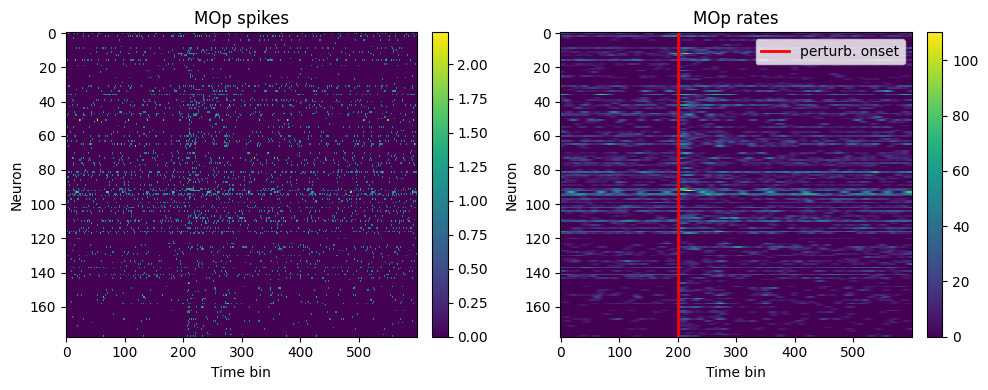

In [ ]:
# Notice this value gives you the time the solenoid turned on relative to the start of the trial
perturb_onset = td.idx_sol_on.iloc[2]   

fig, ax = plt.subplots(figsize=(10, 4), ncols=2)

# Convert to (neurons × time) for image-style plotting
m1_spikes = np.asarray(td.MOp_spikes.iloc[2]).T  # (neuron, time)
m1_rates  = np.asarray(td.MOp_rates.iloc[2]).T   # (neuron, time)

im0 = ax[0].imshow(m1_spikes, aspect="auto", interpolation="nearest")
ax[0].set_title("MOp spikes")
ax[0].set_xlabel("Time bin")
ax[0].set_ylabel("Neuron")
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(m1_rates, aspect="auto", interpolation="nearest")
ax[1].axvline(perturb_onset, color="red", linewidth=2, label='perturb. onset')
ax[1].set_title("MOp rates")
ax[1].set_xlabel("Time bin")
ax[1].set_ylabel("Neuron")
ax[1].legend()
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()

## Kinematic data

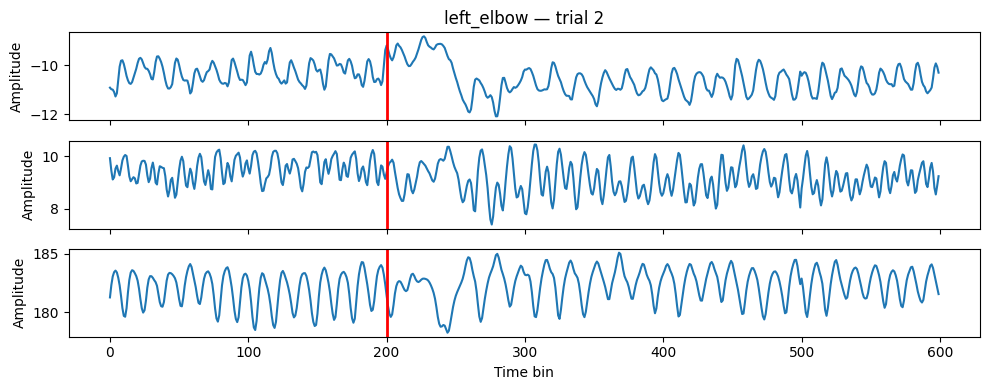

In [45]:
signal_col = 'left_elbow'
trial_idx = 2
perturb_onset = td.idx_sol_on.iloc[2]
kin = np.asarray(td[signal_col].iloc[trial_idx])  # expected (time, 3)

fig, axs = plt.subplots(3, 1, figsize=(10, 4), sharex='all')
for idx, ax in enumerate(axs):
    ax.plot(kin[:, idx])
    ax.axvline(perturb_onset, color="red", linewidth=2)
    ax.set_ylabel("Amplitude")


axs[0].set_title(f"{signal_col} — trial {trial_idx}")
ax.set_xlabel("Time bin")
plt.tight_layout()


# Analysing the data

## Slicing in time

In [ ]:
trial_td = pyal.select_trials(td, td.trial_name == 'trial')
perturb_td = pyal.restrict_to_interval(trial_td, start_point_name='idx_sol_on', rel_start=-200, rel_end=200)
print(f'Trial length before slicing: {trial_period_length} seconds')
print(f'Trial length after slicing: {perturb_td.MOp_rates.values[0].shape[0]} bins')

Trial length before slicing: 6.0 seconds
Trial length after slicing: 301 bins


## Applying a dim reduction model

In [52]:
from sklearn.decomposition import PCA

signal = 'MOp_rates'

pca_model = PCA()
concatenated_data = np.concatenate(perturb_td[signal].values)  ## Concatenate all trials in time
pca_model.fit(concatenated_data)
perturb_td = pyal.apply_dim_reduce_model(perturb_td, pca_model, signal=signal, out_fieldname=f'{signal}_pca')

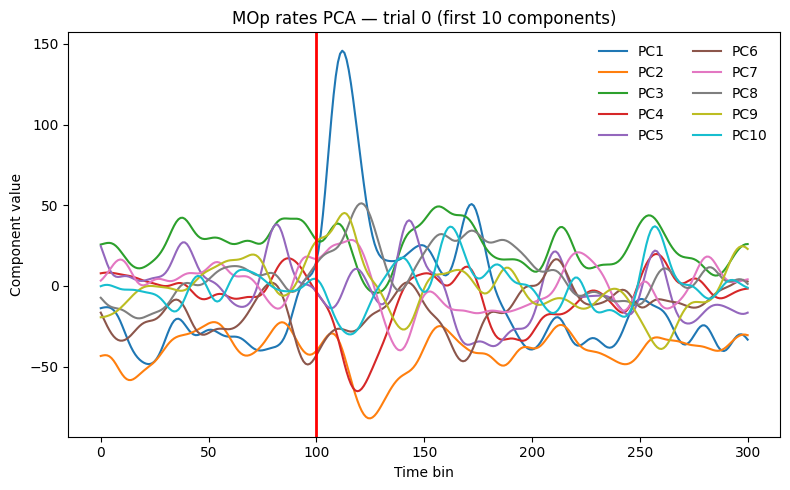

In [64]:
pcs = np.asarray(perturb_td.MOp_rates_pca.iloc[0])
pcs = pcs[:, :10]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pcs)
ax.set_title("MOp rates PCA — trial 0 (first 10 components)")
ax.set_xlabel("Time bin")
ax.set_ylabel("Component value")
ax.axvline(perturb_onset - 100, color="red", linewidth=2)  ## Because we sliced, the trial is only 3 sconds long

ax.legend([f"PC{i+1}" for i in range(pcs.shape[1])], ncol=2, frameon=False)
plt.tight_layout()